## Load Data

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/news.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## Basic Exploration 

In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

## Headline Length

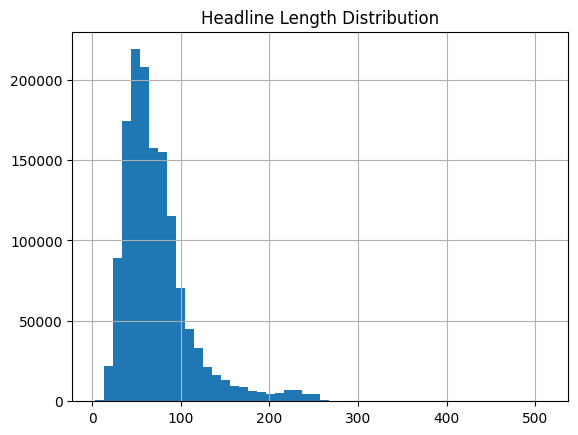

In [6]:
df["headline_length"] = df["headline"].str.len()

df["headline_length"].describe()

import matplotlib.pyplot as plt

df["headline_length"].hist(bins=50)
plt.title("Headline Length Distribution")
plt.show()

## Publisher Analyisis

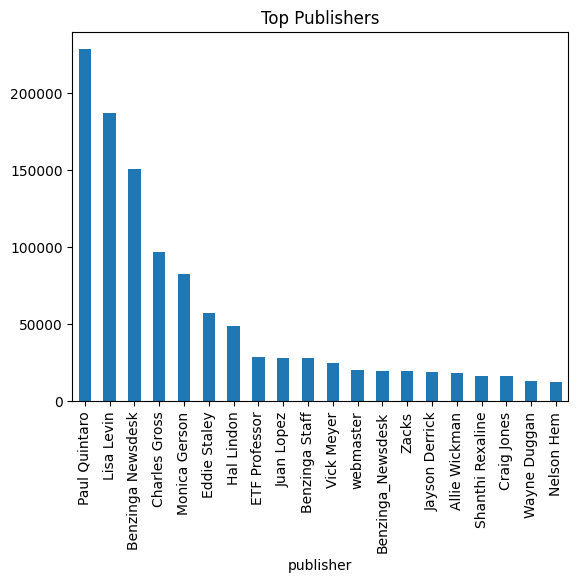

In [7]:
publisher_counts = df["publisher"].value_counts().head(20)

publisher_counts.plot(kind="bar")
plt.title("Top Publishers")
plt.show()

### Conversion of dates

In [10]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    utc=True,
    errors="coerce"
)

## Daily Articles Count

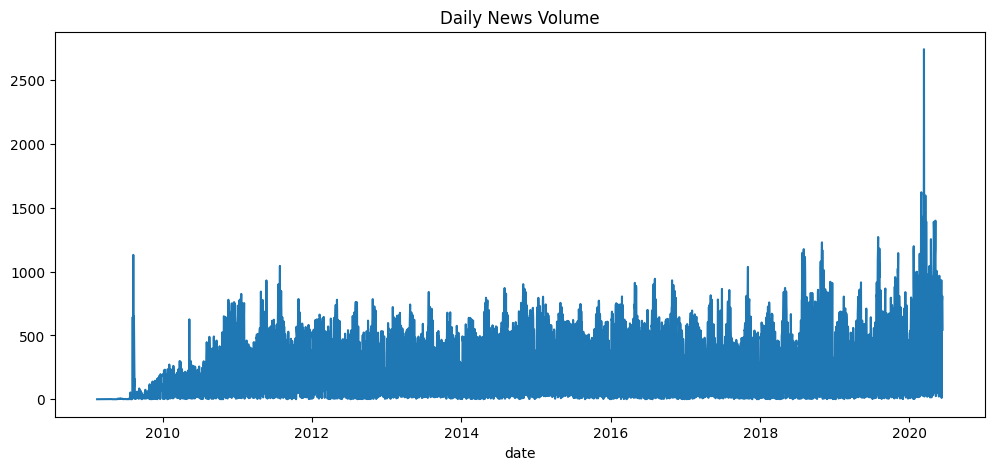

In [11]:
daily_news = df.groupby(df["date"].dt.date).size()

daily_news.plot(figsize=(12,5))
plt.title("Daily News Volume")
plt.show()

## Keywords Analysis

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df["headline"])

keywords = vectorizer.get_feature_names_out()

print(keywords)

['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']
